In [2]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
from scipy.signal import firwin, butter, lfilter
from scipy.fft import fft


Matplotlib is building the font cache; this may take a moment.


Sample Rate: 44100 Hz | Duration: 70.50 seconds


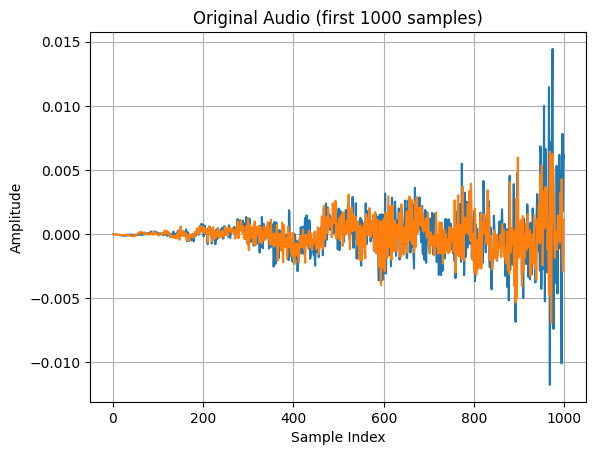

In [3]:

signal, fs = sf.read('817043__vein_adams__footsteps-human-leaves-sidewalk-sneakers-ambience-wind-birds-walk-run.wav')
print(f"Sample Rate: {fs} Hz | Duration: {len(signal)/fs:.2f} seconds")


plt.plot(signal[:1000])
plt.title("Original Audio (first 1000 samples)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid()
plt.show()


In [5]:

if signal.ndim == 2:
    print("Stereo detected — converting to mono...")
    signal = np.mean(signal, axis=1)


noise = 0.02 * np.random.normal(0, 1, len(signal))
noisy_signal = signal + noise


Stereo detected — converting to mono...


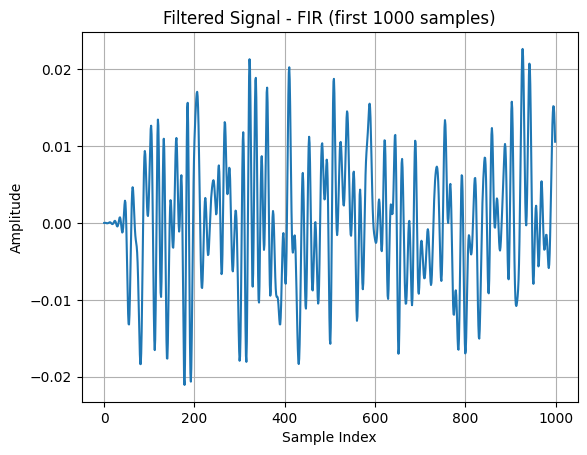

In [6]:
from scipy.signal import firwin, lfilter


numtaps = 101             
cutoff_hz = 4000          

# Design FIR filter
fir_coeff = firwin(numtaps, cutoff_hz, fs=fs)

# Apply filter to noisy signal
filtered_fir = lfilter(fir_coeff, 1.0, noisy_signal)

# Plot filtered signal (optional)
plt.plot(filtered_fir[:1000])
plt.title("Filtered Signal - FIR (first 1000 samples)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid()
plt.show()


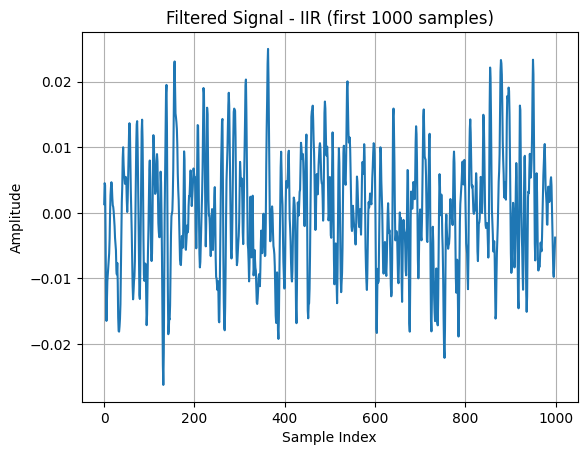

In [7]:
from scipy.signal import butter


b, a = butter(N=2, Wn=cutoff_hz / (fs / 2), btype='low')

# Apply filter
filtered_iir = lfilter(b, a, noisy_signal)


plt.plot(filtered_iir[:1000])
plt.title("Filtered Signal - IIR (first 1000 samples)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid()
plt.show()


In [9]:
from scipy.fft import fft

def plot_fft(signal, fs, title="FFT"):
    N = len(signal)
    freq = np.linspace(0, fs, N)
    magnitude = np.abs(fft(signal))

    plt.figure(figsize=(10, 4))
    plt.plot(freq[:N//2], magnitude[:N//2])  
    plt.title(title)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.grid()
    plt.tight_layout()
    plt.show()


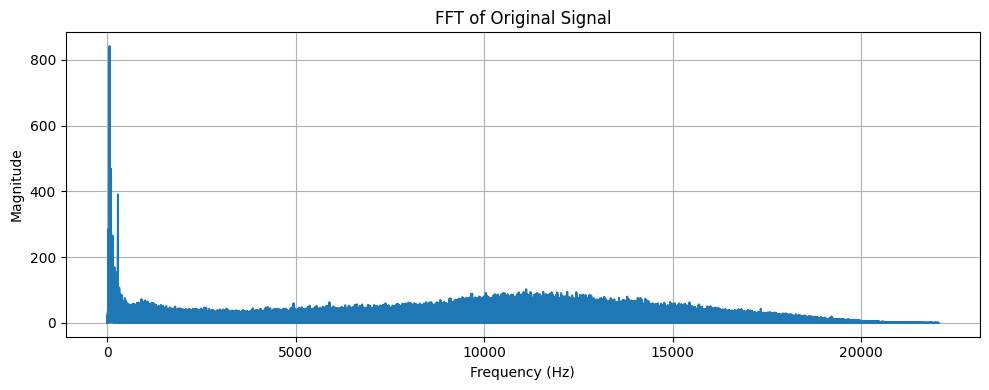

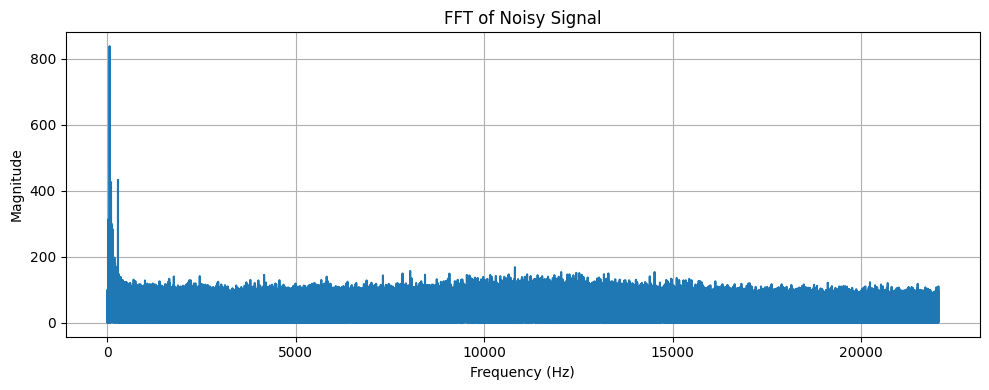

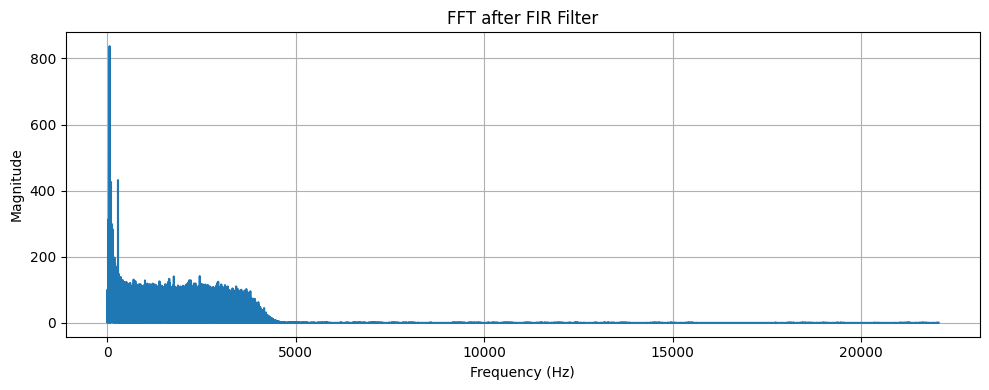

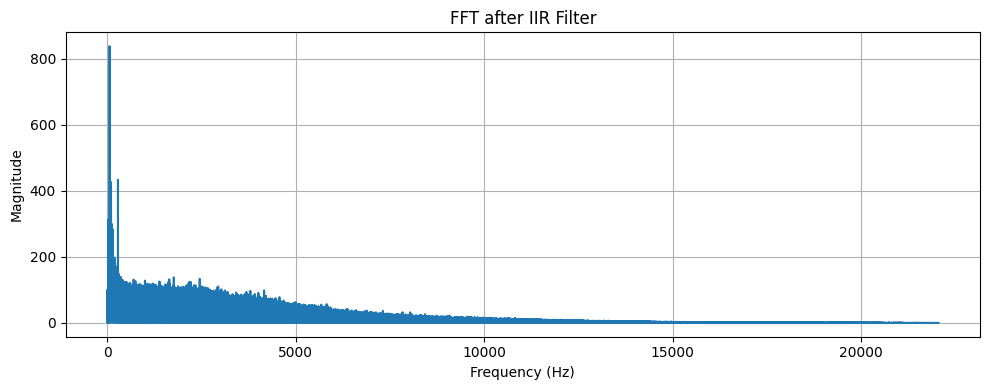

In [10]:
plot_fft(signal, fs, "FFT of Original Signal")
plot_fft(noisy_signal, fs, "FFT of Noisy Signal")
plot_fft(filtered_fir, fs, "FFT after FIR Filter")
plot_fft(filtered_iir, fs, "FFT after IIR Filter")


In [11]:
import soundfile as sf

sf.write("original_mono.wav", signal, fs)
sf.write("noisy_signal.wav", noisy_signal, fs)
sf.write("filtered_fir.wav", filtered_fir, fs)
sf.write("filtered_iir.wav", filtered_iir, fs)


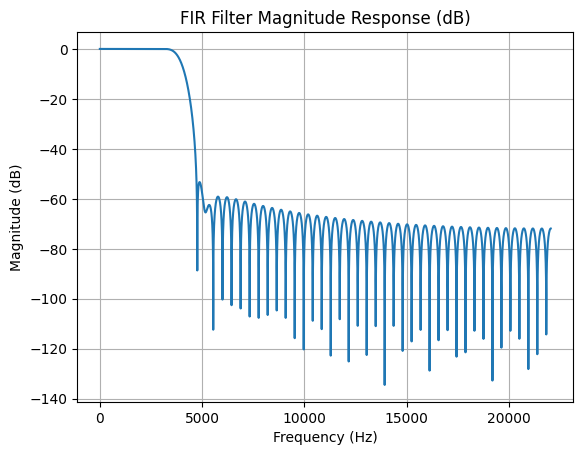

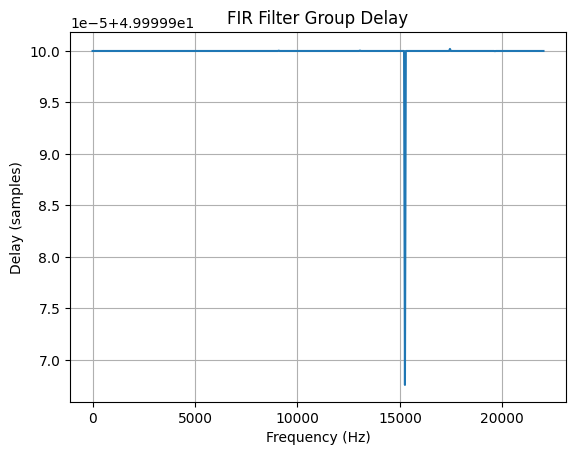

In [12]:
from scipy.signal import freqz, group_delay


w, h = freqz(fir_coeff, worN=8000, fs=fs)
plt.plot(w, 20 * np.log10(abs(h)))
plt.title("FIR Filter Magnitude Response (dB)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.grid()
plt.show()


w, gd = group_delay((fir_coeff, 1), fs=fs)
plt.plot(w, gd)
plt.title("FIR Filter Group Delay")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Delay (samples)")
plt.grid()
plt.show()


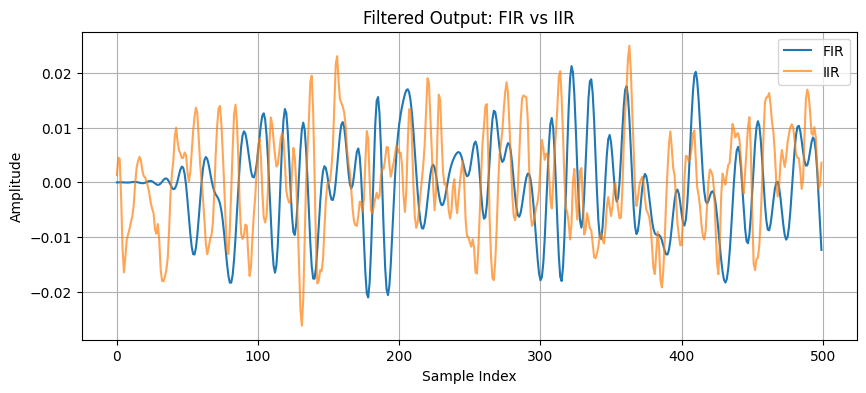

In [13]:
plt.figure(figsize=(10,4))
plt.plot(filtered_fir[:500], label='FIR')
plt.plot(filtered_iir[:500], label='IIR', alpha=0.7)
plt.legend()
plt.title("Filtered Output: FIR vs IIR")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid()
plt.show()


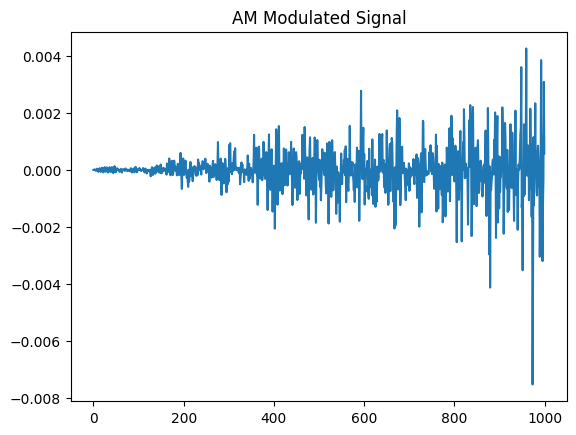

In [14]:
carrier_freq = 8000  # Hz
t = np.arange(len(signal)) / fs
carrier = np.cos(2 * np.pi * carrier_freq * t)
modulated = signal * carrier

plt.plot(modulated[:1000])
plt.title("AM Modulated Signal")
plt.show()
